# Experiment 2 — model-family comparison
Five conservative, untuned tabular classifiers on the exact Phase 1 folds. No engineered features, external data, or leaderboard feedback are used.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from kaggle_smartphone_addiction import CVConfig, load_competition_data, split_features_target
from kaggle_smartphone_addiction.model_comparison import compare_models, prepare_catboost, prepare_native_categories
train, test, sample = load_competition_data(ROOT / 'data/raw')
X, y, X_test = split_features_target(train, test)
CVConfig()

CVConfig(n_splits=5, shuffle=True, random_state=42)

## Reproduction switch
The complete benchmark is intentionally opt-in because it fits 25 large models. The committed report is loaded by default; set `RUN_FULL_BENCHMARK=True` to regenerate it using the same reusable runner.

In [2]:
RUN_FULL_BENCHMARK = False
if RUN_FULL_BENCHMARK:
    X_native, _, categorical = prepare_native_categories(X, X_test)
    X_catboost, _, _ = prepare_catboost(X, X_test)
    comparison, _ = compare_models(X, y, X_native, X_catboost, categorical, CVConfig())
    comparison.to_csv(ROOT / 'reports/model_comparison.csv', index=False)
else:
    comparison = pd.read_csv(ROOT / 'reports/model_comparison.csv')

## Fold-level ROC AUC

In [3]:
fold_table = comparison.pivot(index='model', columns='fold', values='fold_auc')
fold_table.columns = [f'fold_{c}' for c in fold_table.columns]
fold_table.sort_values('fold_1', ascending=False).style.format('{:.6f}')

,fold_1,fold_2,fold_3,fold_4,fold_5
model,,,,,
XGBoost,0.959851,0.960405,0.960996,0.961500,0.960238
LightGBM,0.959638,0.960520,0.961029,0.961642,0.960196
HistGradientBoosting,0.955961,0.957658,0.957792,0.956919,0.957472
CatBoost,0.952432,0.953124,0.953431,0.954344,0.953210
LogisticRegression,0.912733,0.913081,0.914453,0.914733,0.913933


## OOF performance and runtime

In [4]:
summary_columns = [
    'model', 'oof_auc', 'oof_log_loss', 'oof_accuracy_0.5',
    'mean_fold_auc', 'std_fold_auc', 'delta_vs_logistic',
    'total_fit_seconds', 'total_predict_seconds', 'max_model_size_mb',
]
summary = comparison.drop_duplicates('model')[summary_columns].sort_values('oof_auc', ascending=False)
summary.style.format({c: '{:.6f}' for c in summary.columns if c != 'model'})

,model,oof_auc,oof_log_loss,oof_accuracy_0.5,mean_fold_auc,std_fold_auc,delta_vs_logistic,total_fit_seconds,total_predict_seconds,max_model_size_mb
15,LightGBM,0.960604,0.232012,0.897583,0.960605,0.000769,0.046819,12.610080,1.436492,1.055478
10,XGBoost,0.960596,0.231060,0.897386,0.960598,0.000651,0.046811,11.913947,0.381886,1.389782
5,HistGradientBoosting,0.957157,0.242273,0.892334,0.957160,0.000748,0.043372,12.550172,0.993725,0.644790
20,CatBoost,0.953305,0.251253,0.886893,0.953308,0.000689,0.039520,103.038239,0.212468,0.344263
0,LogisticRegression,0.913785,0.338347,0.842285,0.913787,0.000861,0.000000,4.912638,0.384170,0.004467


LightGBM leads XGBoost by only 0.0000074 AUC—an effective tie. LightGBM is the deterministic champion on primary OOF AUC, while XGBoost has marginally lower fold variance, better log loss, and faster inference. CatBoost is stable but substantially slower to fit under these conservative settings.

## Champion feature importance

,feature,importance,importance_normalized
0,notifications_per_day,1645,0.182778
1,app_opens_per_day,1643,0.182556
2,daily_screen_time_hours,1236,0.137333
3,weekend_screen_time,1140,0.126667
4,social_media_hours,1037,0.115222
5,work_study_hours,780,0.086667
6,gaming_hours,687,0.076333
7,sleep_hours,471,0.052333
8,age,264,0.029333
9,gender,35,0.003889


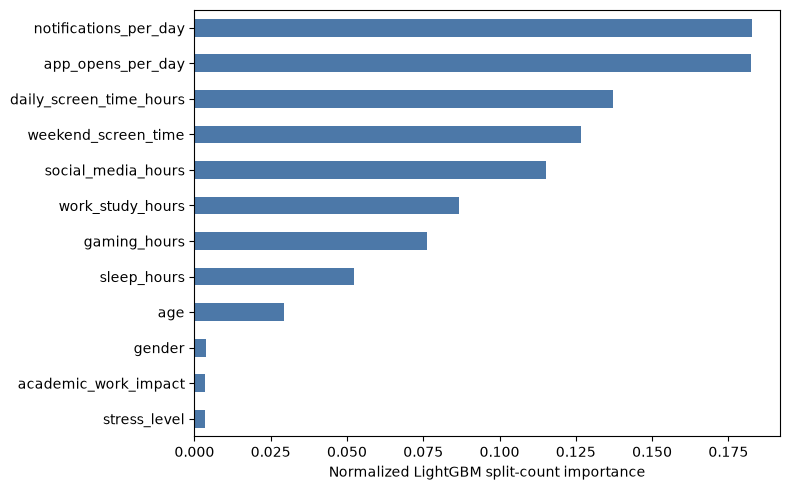

In [5]:
importance = pd.read_csv(ROOT / 'reports/feature_importance.csv')
ax = importance.sort_values('importance_normalized').plot.barh(
    x='feature', y='importance_normalized', legend=False, figsize=(8, 5), color='#4C78A8'
)
ax.set(xlabel='Normalized LightGBM split-count importance', ylabel='')
plt.tight_layout()
importance.head(12)

Split-count importance is fast reconnaissance, not a causal interpretation, and can favor continuous features with many candidate thresholds. A held-out permutation or SHAP stability study is a natural follow-up.

## Decision
LightGBM is the current champion and clearly beats logistic regression (+0.046819 OOF AUC), so it was fitted on all labeled data and used to create the locally validated `submission_02_model.csv`. No Kaggle submission was made.